<a href="https://colab.research.google.com/github/RobertsEshenvalds/test/blob/main/Copy_of_07_decision_trees_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Decision Trees: Fill-in-the-Gaps Exercise

**Dataset:** Wine dataset from `sklearn.datasets`

In this exercise you will build a Decision Tree classifier step by step.  
Each code cell has **gaps** marked with `____` — replace them with the correct code.

> This is the **exercise** version — fill in all the blanks!

## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_wine          # function to load the wine dataset
from sklearn.model_selection import train_test_split   # function to split data
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

## 2. Load and Explore the Dataset

The Wine dataset contains 13 numeric features describing chemical properties of wines from three different cultivars (classes 0, 1, 2).

In [ ]:
# Load the wine dataset
wine = load_wine()
# Create a DataFrame from the data and feature names
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target
print(f"Shape: {df.shape}")
df.head()


Shape: (178, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## 3. Prepare Features and Split the Data

Separate features (`X`) from the target (`y`), then split into training and test sets.

In [ ]:
# Separate features and target
X = df.drop('target', axis=1)
y = df['target']
# Split: 70 % train, 30 % test, random_state=42 for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.3, random_state=42
)
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

Training samples: 124
Test samples: 54


## 4. Train a Decision Tree

Create a `DecisionTreeClassifier` with `max_depth=3` and `random_state=42`, then fit it on the training data.

In [ ]:
# Create the classifier
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
# Fit on training data
clf.fit(X_train, y_train)
print("Model trained funccessfully!")

Model trained funccessfully!


## 5. Make Predictions and Evaluate

In [ ]:
# Predict on the test set
y_pred = clf.predict(X_test)
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.2%}")
print()
print(classification_report(y_test, y_pred, target_names=wine.target_names))


Test Accuracy: 96.30%

              precision    recall  f1-score   support

     class_0       1.00      0.95      0.97        19
     class_1       0.91      1.00      0.95        21
     class_2       1.00      0.93      0.96        14

    accuracy                           0.96        54
   macro avg       0.97      0.96      0.96        54
weighted avg       0.97      0.96      0.96        54



## 6. Visualise the Tree

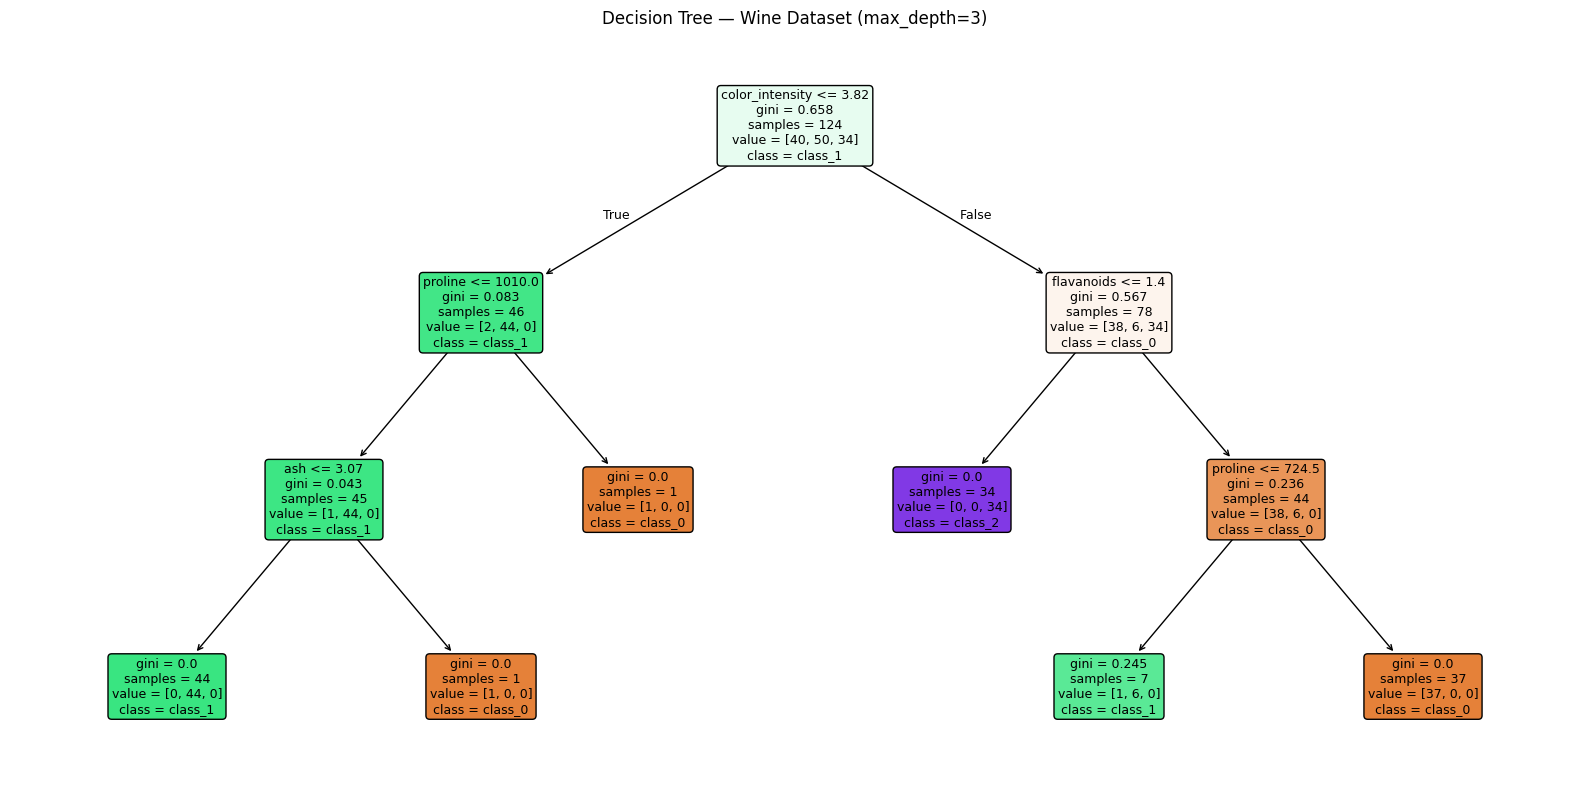

In [ ]:
plt.figure(figsize=(16, 8))
plot_tree(
clf,
feature_names=wine.feature_names,
class_names=wine.target_names,
filled=True,
rounded=True,
fontsize=9,
)
plt.title("Decision Tree — Wine Dataset (max_depth=3)")
plt.tight_layout()
plt.show()

## 7. Feature Importance

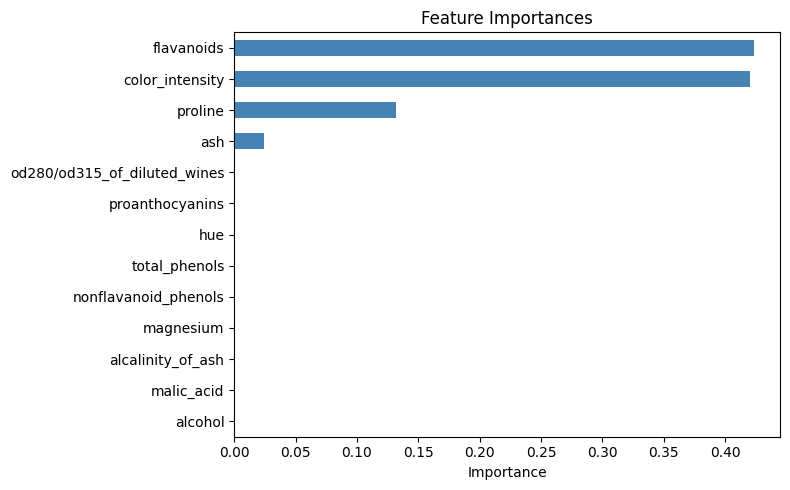

In [ ]:
importances = pd.Series(clf.feature_importances_, index=wine.feature_names)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='steelblue')
plt.title("Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## 8. Bonus: Effect of `max_depth`

Try different values of `max_depth` and observe how training and test accuracy change.

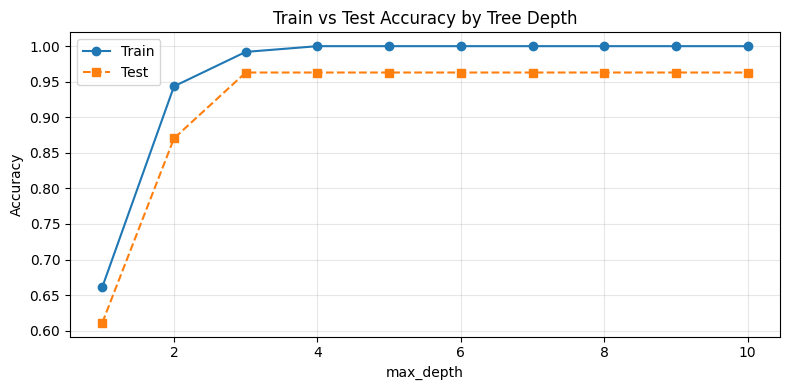

In [ ]:
depths = range(1, 11)
train_acc = []
test_acc = []

for d in depths:
  model = DecisionTreeClassifier(max_depth=d, random_state=42)
  model.fit(X_train, y_train)
  train_acc.append(accuracy_score(y_train, model.predict(X_train)))
  test_acc.append(accuracy_score(y_test, model.predict(X_test)))
plt.figure(figsize=(8, 4))
plt.plot(depths, train_acc, 'o-', label='Train')
plt.plot(depths, test_acc, 's--', label='Test')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy by Tree Depth')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
